### 📚 Lesson 3.3: Backpropagation – Dạy mạng nhiều lớp học như thế nào?

---

**Mày đã học gì rồi?**

* Loss function: đo sai số (MSE, Cross-Entropy).
* Gradient Descent: dùng đạo hàm để cập nhật weight, giảm loss.
* Mày đã code 1 regression mini với Gradient Descent, cho ra w ≈ 2 ngon lành.

---

#### ❓ Today's question

“Nếu mạng có nhiều layer thì làm sao tính gradient để update weight của từng layer?”

---

#### 💡 Key ideas

* **Forward pass:** tính output qua từng layer.
* **Backward pass (Backpropagation):** dùng chain rule để tính đạo hàm loss theo từng weight.

Công thức:

* Với 1 neuron:

  $$
  y = f(w \cdot x + b)
  $$
* Gradient lan ngược từ output về input nhờ **chain rule**:

  $$
  \frac{\partial L}{\partial w} = \frac{\partial L}{\partial y} \cdot f'(z) \cdot x
  $$

  với $z = w \cdot x + b$.

👉 Nói ngắn: Backpropagation = **Gradient Descent + Chain Rule**, lan ngược qua tất cả layer để update weight.

---

#### 📝 Practice Problems

1. **Knowledge check:**

   * Backpropagation dựa vào quy tắc toán học nào để tính gradient?
   * Nói 1 câu: Forward pass khác gì Backward pass?

2. **Coding (mini neural net from scratch):**
   Code bằng numpy 1 mạng **2-layer** (input → hidden → output) cho bài toán đơn giản: học hàm **XOR**.

   Gợi ý:

   * Input:

     ```python
     X = np.array([[0,0],[0,1],[1,0],[1,1]])
     Y = np.array([[0],[1],[1],[0]])
     ```
   * Hidden layer: 2 neurons, activation = sigmoid
   * Output layer: 1 neuron, activation = sigmoid
   * Loss = MSE
   * Train bằng backprop trong \~10k epochs, đến khi output gần đúng \[0,1,1,0].

👉 Đây là coding tập to đùng: tự tay implement forward + backward.

---

#### 🧩 Solution


**Question 1:**

- Forward pass: input -> $f(w\cdot x + b)$ -> output ($y$)
- Backward pass: output ($y$) -> $L$ -> $\frac{\partial L}{\partial y}$ -> $\frac{\partial L}{\partial w}$

**Question 2:**

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([[0], [1], [1], [0]])

n = X.shape[0]

In [3]:
# activation functions
sigmoid = lambda z: 1 / (1 + np.exp(-z))
sigmoid_deriv = lambda a: a * (1 - a)

tanh = np.tanh
tanh_deriv = lambda a: 1 - a**2

# loss functions
mse = lambda y_pred, y_true: ((y_true - y_pred) ** 2).mean()
mse_deriv = lambda y_pred, y_true: 2 * (y_pred - y_true)

In [4]:
lr = 0.1
epochs = 10000

# hidden layer: 2 neurons, activation = tanh
W1 = np.random.randn(2, 2) * 0.1
b1 = np.zeros((1, 2))

# output layer: 1 neuron, activation = sigmoid
W2 = np.random.randn(2, 1) * 0.1
b2 = np.zeros((1, 1))

In [5]:
def forward():
    z1 = X@W1 + b1		# (n, 2)
    a1 = tanh(z1)		# (n, 2)

    z2 = a1@W2 + b2		# (n, 1)
    a2 = sigmoid(z2)	# (n, 1)

    return a1, a2

In [ ]:
def training_step():
    global W1, b1, W2, b2
    a1, a2 = forward()

    # Backprop output layer
    grad_y2 = mse_deriv(a2, Y)				# (n, 1)
    grad_z2 = grad_y2 * sigmoid_deriv(a2)	# (n, 1)
    grad_W2 = a1.T @ grad_z2				# (2, 1)
    grad_b2 = grad_z2.sum(axis=0)			# (1,)

    # Backprop hidden layer
    grad_y1 = grad_z2 @ W2.T				# (n, 2)
    grad_z1 = grad_y1 * tanh_deriv(a1)		# (n, 2)
    grad_W1 = X.T @ grad_z1					# (2, 2)
    grad_b1 = grad_z1.sum(axis=0)			# (2,)

    # Gradient Descent
    W1 -= lr * grad_W1
    b1 -= lr * grad_b1
    W2 -= lr * grad_W2
    b2 -= lr * grad_b2

    return a2

In [7]:
loss_records = []
for _ in tqdm(range(epochs)):
    y_pred = training_step()
    loss_records.append(mse(y_pred, Y))

100%|██████████| 10000/10000 [00:00<00:00, 44974.36it/s]


In [8]:
print(f"Final loss: {loss_records[-1]:.4f}")
print(forward()[1].T[0])

Final loss: 0.0003
[0.01798944 0.98641548 0.98641188 0.01881656]


---

#### 🚀 Bonus

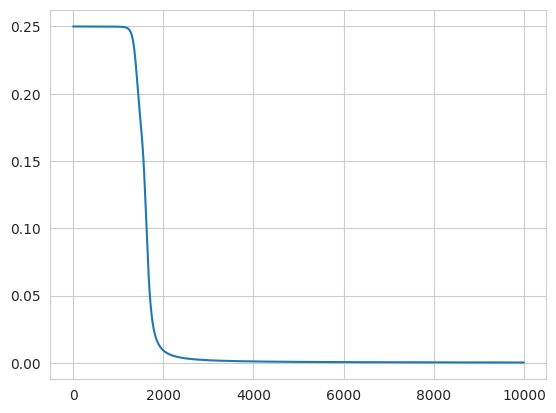

In [9]:
sns.set_style("whitegrid")
sns.lineplot(x=range(epochs), y=loss_records)
plt.show()